Mounted at /content/drive
✅ Libraries loaded
✅ Config loaded
   Datasets      : 11
   Train/Test    : 70% / 30%
   n_estimators  : 100
   max_features  : sqrt
   class_weight  : balanced
  Random Forest — Training & Evaluation on 11 Datasets

────────────────────────────────────────────────────────────
  Dataset : AAC  (AAC_features.csv)
  Shape   : (2190, 21)  |  Features: 20  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples

  ── Results ──────────────────────────────────────
  Accuracy    : 0.7915
  Sensitivity : 0.6502
  Specificity : 0.8858
  F1 Score    : 0.7140
  MCC         : 0.5590
  AUC         : 0.8284
  TP=171  TN=349  FP=45  FN=92
  Probabilities saved → /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/random_forest/AAC_RF_probabilities.csv

────────────────────────────────────────────────────────────
  Dataset : DPC  (DPC_features.csv)
  Shape   : (2190, 401)  |  Features: 400  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657

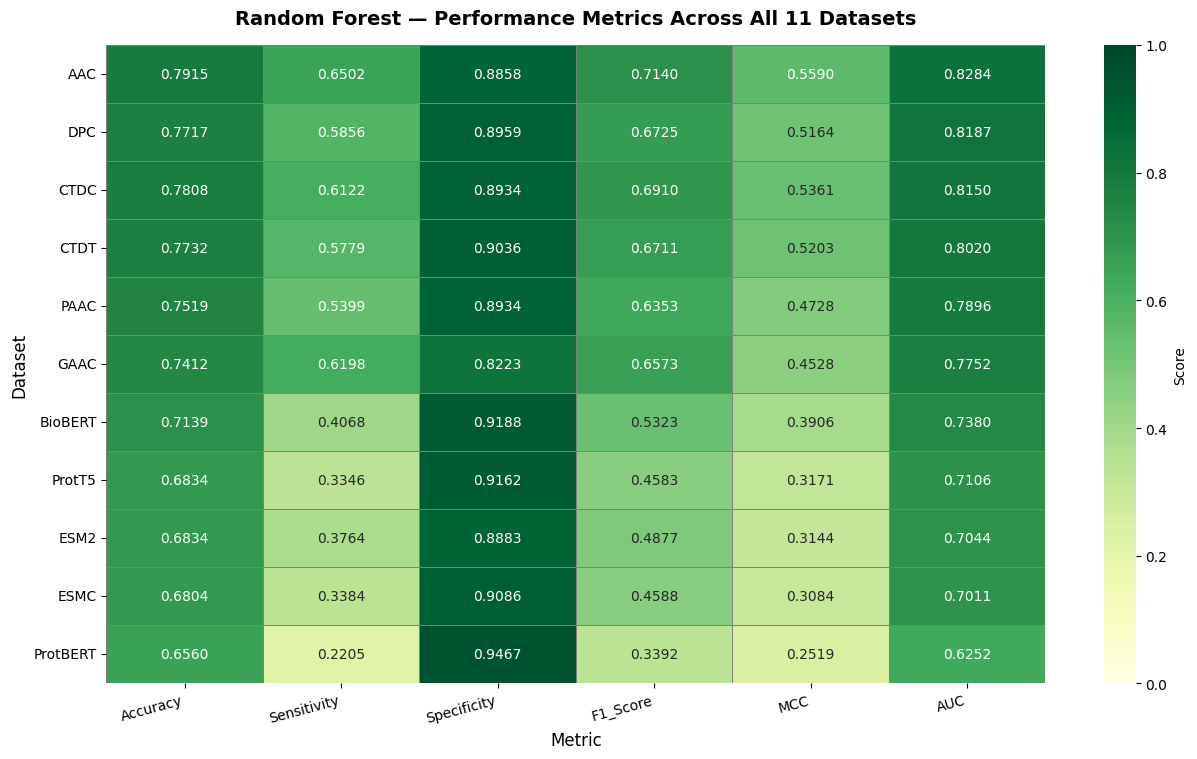

✅ Metrics heatmap saved


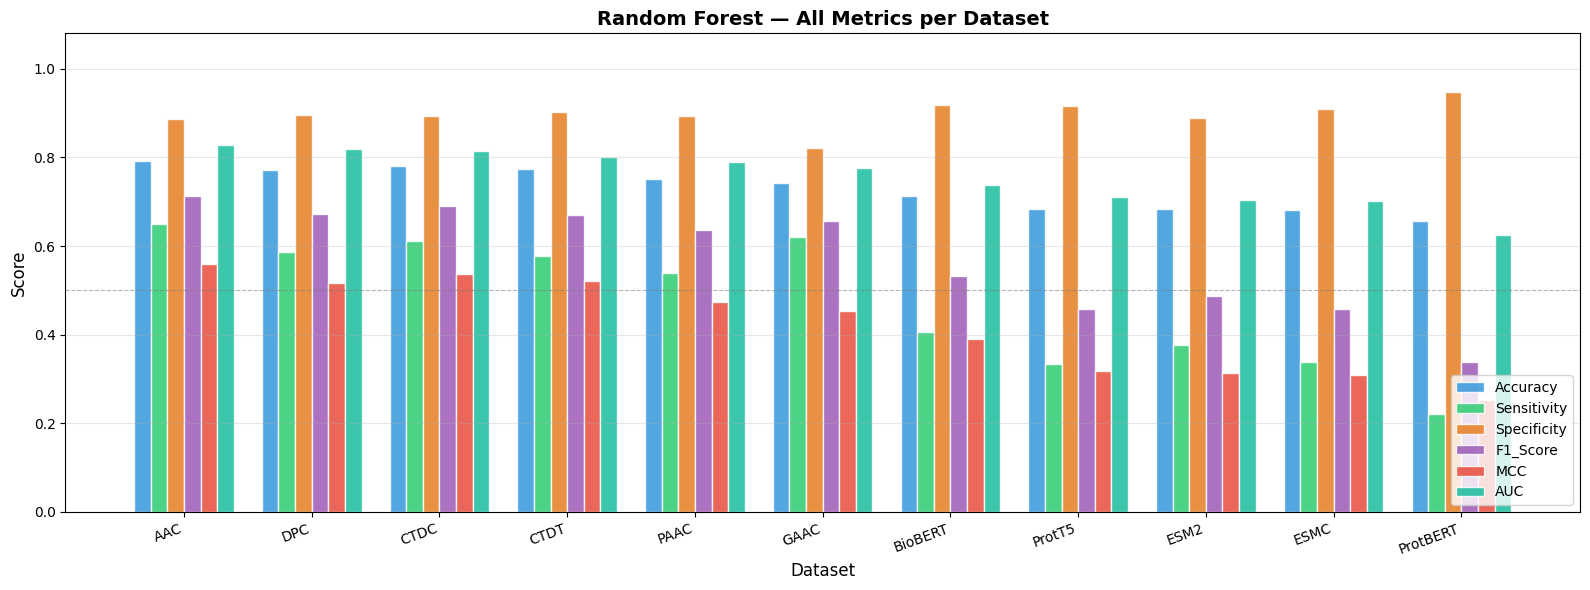

✅ Grouped bar chart saved


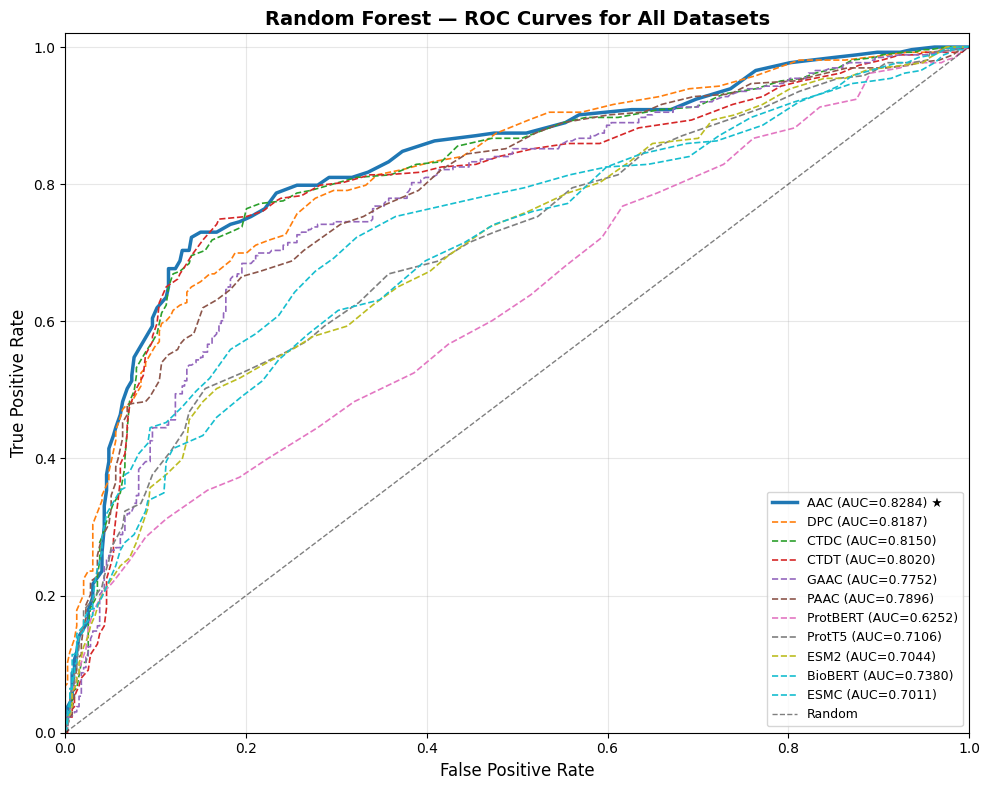

✅ ROC curves saved


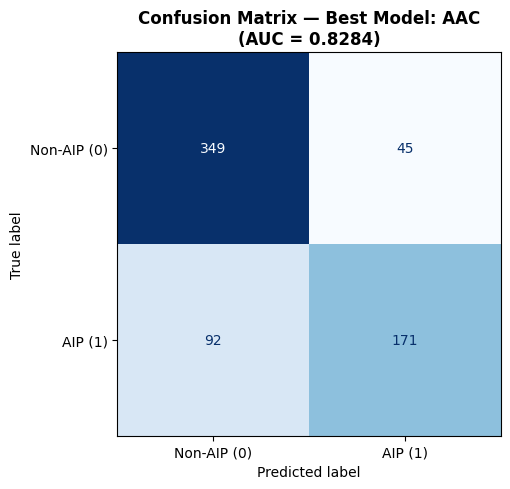

✅ Confusion matrix saved (AAC)


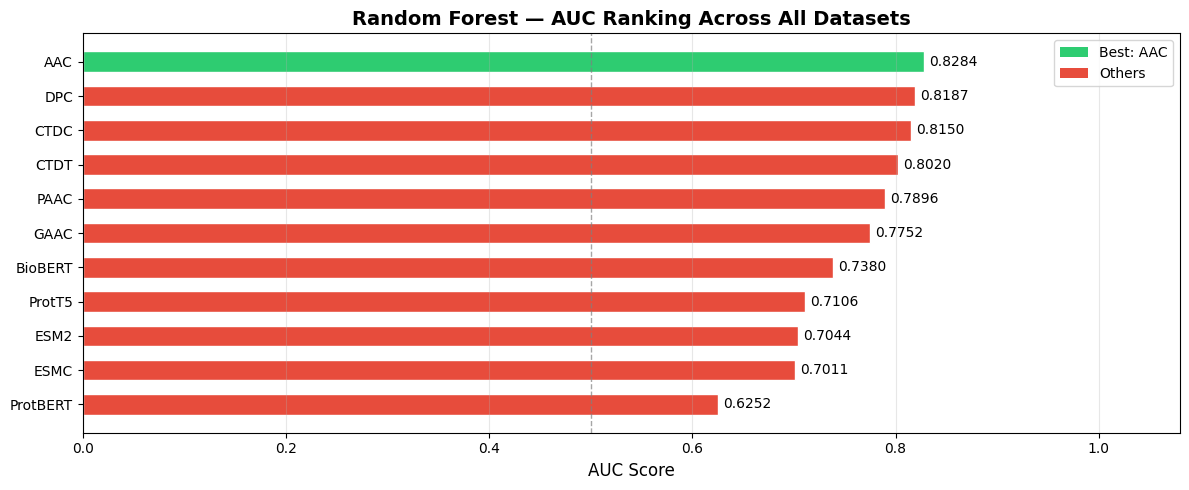

✅ AUC ranking chart saved


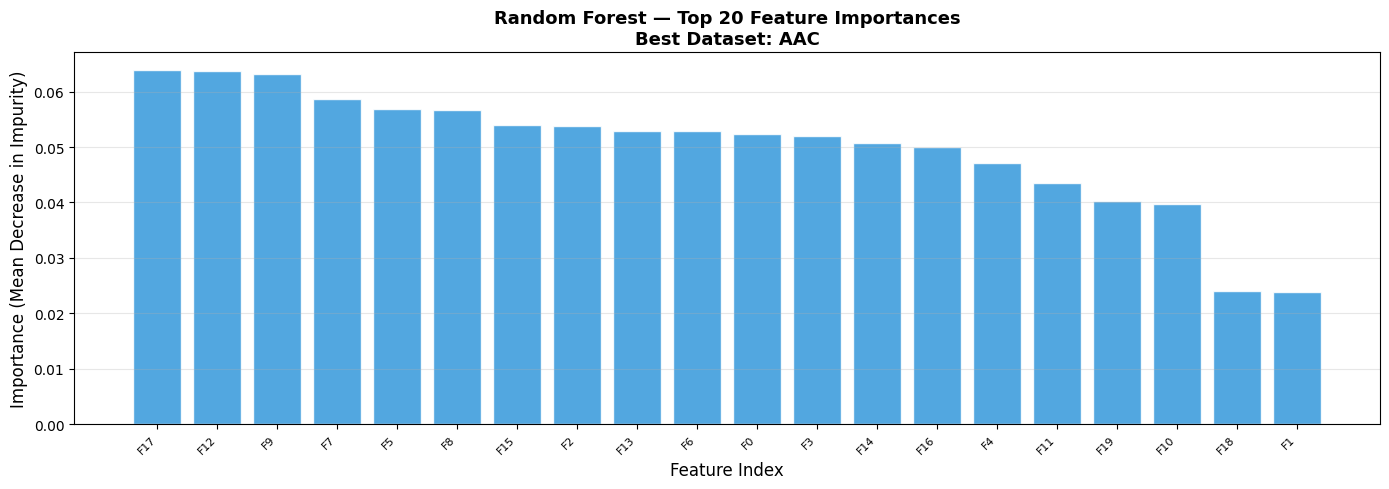

✅ Feature importance plot saved (AAC)
  RANDOM FOREST — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/random_forest
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/random_forest
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/random_forest

─────────────────────────────────────────────────────────────────
  Dataset           Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  AAC            0.7915   0.6502   0.8858   0.7140   0.5590   0.8284 ★
  DPC            0.7717   0.5856   0.8959   0.6725   0.5164   0.8187
  CTDC           0.7808   0.6122   0.8934   0.6910   0.5361   0.8150
  CTDT           0.7732   0.5779   0.9036   0.6711   0.5203   0.8020
  PAAC           0.7519   0.5399   0.8934   0.6353   0.4728   0.7896
  GAAC           0.7412   0.6198   0.8223   0.6573   0.4528   0.7752
  BioBERT 

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print("✅ Libraries loaded")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/random_forest"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/random_forest"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/random_forest"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── Random Forest hyperparameters ────────────────────────────
#
#  Key RF parameters:
#    n_estimators    : number of trees — more = better but slower
#                      100 is a safe default; try 200/500 for PLM features
#    max_depth       : None = fully grown trees
#                      set 10/20 to reduce overfitting on high-dim PLM data
#    max_features    : "sqrt" = √(n_features) per split (default, good for classification)
#                      "log2" or float (e.g. 0.3) are alternatives
#    min_samples_leaf: minimum samples at a leaf node — higher = more regularization
#    class_weight    : "balanced" adjusts for 1:1.5 AIP/non-AIP imbalance
#    n_jobs          : -1 uses all CPU cores for parallel training
#
RF_PARAMS = {
    "n_estimators"     : 100,
    "criterion"        : "gini",      # "gini" or "entropy"
    "max_depth"        : None,
    "max_features"     : "sqrt",
    "min_samples_split": 2,
    "min_samples_leaf" : 1,
    "class_weight"     : "balanced",
    "n_jobs"           : -1,
    "random_state"     : 42,
}

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets      : {len(DATASETS)}")
print(f"   Train/Test    : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   n_estimators  : {RF_PARAMS['n_estimators']}")
print(f"   max_features  : {RF_PARAMS['max_features']}")
print(f"   class_weight  : {RF_PARAMS['class_weight']}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    return X, y, df.columns[-1], df.shape


# ============================================================
#   CELL 5 — Main Training Loop
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  Random Forest — Training & Evaluation on 11 Datasets")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Scale features ───────────────────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Train Random Forest ──────────────────────────────────
    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_train, y_train)

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]  = ds_name
    metrics["Features"] = X.shape[1]
    metrics["Train_N"]  = len(X_train)
    metrics["Test_N"]   = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR, f"{ds_name}_RF_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test": y_test,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "clf"   : clf,
        "scaler": scaler,
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 6 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "Accuracy", "Sensitivity", "Specificity",
               "F1_Score", "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── Random Forest Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "RF_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 7 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR, f"RF_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR, f"RF_best_scaler_{best_name}.joblib")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

print(f"✅ Best model saved")
print(f"   Dataset : {best_name}")
print(f"   AUC     : {best_auc:.4f}")
print(f"   Model   : {best_model_path}")
print(f"   Scaler  : {best_scaler_path}")


# ============================================================
#   CELL 8 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity", "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("Random Forest — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "RF_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 9 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Random Forest — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"], rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "RF_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 10 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} (AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Random Forest — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "RF_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 11 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"(AUC = {best_auc:.4f})",
             fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"RF_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 12 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df = df_results.sort_values("AUC", ascending=True)
colors    = ["#e74c3c" if n != best_name else "#2ecc71"
             for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, sorted_df["AUC"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("Random Forest — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.08)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "RF_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 13 — Visualization 6: Feature Importance (Best Model)
#             RF provides built-in feature importances — unique
#             advantage over Decision Tree (more stable estimates)
# ============================================================

importances   = best_model.feature_importances_
n_top         = min(30, len(importances))
top_idx       = np.argsort(importances)[::-1][:n_top]
top_imp       = importances[top_idx]
top_labels    = [f"F{i}" for i in top_idx]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(n_top), top_imp, color="#3498db",
       edgecolor="white", alpha=0.85)
ax.set_xticks(range(n_top))
ax.set_xticklabels(top_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Feature Index", fontsize=12)
ax.set_ylabel("Importance (Mean Decrease in Impurity)", fontsize=12)
ax.set_title(f"Random Forest — Top {n_top} Feature Importances\n"
             f"Best Dataset: {best_name}",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, f"RF_feature_importance_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Feature importance plot saved ({best_name})")


# ============================================================
#   CELL 14 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  RANDOM FOREST — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'Acc':>8} {'Sn':>8} {'Sp':>8} "
      f"{'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {row['Accuracy']:>8.4f} "
          f"{row['Sensitivity']:>8.4f} {row['Specificity']:>8.4f} "
          f"{row['F1_Score']:>8.4f} {row['MCC']:>8.4f} "
          f"{row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset : {best_name}")
print(f"     Accuracy     : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity  : {best_row['Sensitivity']:.4f}")
print(f"     Specificity  : {best_row['Specificity']:.4f}")
print(f"     F1 Score     : {best_row['F1_Score']:.4f}")
print(f"     MCC          : {best_row['MCC']:.4f}")
print(f"     AUC          : {best_row['AUC']:.4f}")
print(f"\n  RF vs DT advantage:")
print(f"     ✅ Ensemble of {RF_PARAMS['n_estimators']} trees → less overfitting")
print(f"     ✅ Built-in feature importance scores")
print(f"     ✅ More stable predictions via bagging")
print("=" * 65)